# E3.x — Cross-Solvent Synthesis

Reads the nine per-system E3.x summaries against one another, at matched cutoffs,
to frame the logged observations as **hypotheses supported by the data** — not as
conclusions. Every number is drawn from a committed E3.x section output (CSV or
convergence sidecar); nothing is parsed from the summary markdown, and the
Phase-3/Phase-4 strided SASA columns are not used here.

Three questions, one section each:

- **E3.1** — does the DES-induced SASA change survive corrected CIs across the matrix? (tier-aware, within-peptide row)
- **E3.2** — is the SASA change accompanied by direct DES contact, or consistent with indirect restructuring? (qualitative matrix + matched-cutoff magnitudes)
- **E3.3** — is the YIY reline backbone-H-bond pattern a genuine cross-solvent difference, and in which direction?

Run order: §0 → §1 → §2a → §3 → §4 are pure reductions and complete in a few
minutes. **§2b is the only trajectory-touching section** (guarded + cached,
~5–10 min on first run); it lives at the end so the cheap sections verify first.

Conventions carried from the phase: coordination on pair-specific RDF-derived
first-shell cutoffs with ACF-corrected 95% CIs (`N_eff = N/τ_int`); SASA/Rg from
the E2.2 pooled leave-one-out framework, reported per tier; backbone H-bonds at
1 ps resolution, backbone N→O scope, continuous episodes. No external citations —
`[REF]` placeholders for anything not in a committed output.

## §0 — Configuration, load, inventory

Paths, the system×tier map, and the analysis-window parameters confirmed by the
calibration probe (stride-10, 18,000 frames retained after dropping 0–20 ns).
`RDF_CURVES_AVAILABLE` is `False` — the inventory found `rdfs/` holds derived
cutoffs only, no g(r) arrays — which is why the matched-cutoff magnitudes in §2b
require a trajectory recompute rather than a cheap re-integration.

In [20]:
import os, sys, json, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT  = os.path.expanduser("~/des-peptide-study")
E3X      = os.path.join(PROJECT, "extension/analysis/E3x")
CONV = os.path.join(PROJECT, "extension")
TRAJROOT = os.path.join(PROJECT, "extension/trajectories_extended")
SYSTOP   = os.path.join(PROJECT, "systems")                 # {SYSTEM}/{SYSTEM}.prmtop
OUTDIR   = os.path.join(E3X, "cross_solvent")
os.makedirs(OUTDIR, exist_ok=True)

PEPTIDES = ["GGE", "CME", "YIY"]
SOLVENTS = ["water", "reline", "glyceline"]
SYSTEMS  = [f"{p}_{s}" for p in PEPTIDES for s in SOLVENTS]
STARTS   = ["compact", "mid", "open", "extended"]

TIER = {
    "GGE_reline": "A", "GGE_glyceline": "A", "CME_water": "A",
    "YIY_water": "B", "YIY_reline": "B", "YIY_glyceline": "B",
    "CME_reline": "C",
    "GGE_water": "D", "CME_glyceline": "D",
}

# analysis window (confirmed by calibration): 10 ps/frame; drop 0-20 ns
STRIDE          = 10
WIN_START_FRAME = 2000        # 2000 strided frames == 20 ns -> 18,000 retained
RDF_CURVES_AVAILABLE = False  # inventory: rdfs/ holds cutoffs only

# trajectory path convention (confirmed by the size/glob probe)
def traj_path(system, start):
    tag = f"{system}_200ns_{start}_r1"
    return os.path.join(TRAJROOT, tag, tag + ".dcd")

def top_path(system):
    return os.path.join(SYSTOP, system, system + ".prmtop")

print("outputs ->", OUTDIR)
print("systems  :", ", ".join(SYSTEMS))

outputs -> /Users/rossgibson/des-peptide-study/extension/analysis/E3x/cross_solvent
systems  : GGE_water, GGE_reline, GGE_glyceline, CME_water, CME_reline, CME_glyceline, YIY_water, YIY_reline, YIY_glyceline


In [21]:
import sys, os, inspect
sys.path.insert(0, os.path.expanduser("~/des-peptide-study/extension"))
import convergence_stats as cs
print([n for n in dir(cs) if not n.startswith("_")])
print("compute_stat:", inspect.signature(cs.compute_stat))
print(inspect.getsource(cs.compute_stat).split("return")[-1][:200])

['DEFAULT_C', 'DISCARD_NS', 'DT_PS', 'SAVE_INTERVAL_PS', 'STRIDE', 'TAU_FLOOR', 'autocorr_func_1d', 'compute_stat', 'integrated_time', 'np', 'pairwise', 'pd', 'pooled_stability', 'prepare_series', 'verdict']
compute_stat: (series, dt_ps=10.0)
 {"mean": float(series.mean()),
            "tau_int_ns": tau * dt_ps / 1000.0,
            "N_eff": n_eff,
            "se": float(se),
            "ci95": 1.96 * float(se)}



### §0.1 — Load section outputs and build the manifest

One row per system; a `True`/`False` per expected section file. This is the
gate: any `False` is a gap to backfill before the synthesis leans on it.

In [22]:
SECTION_FILES = {
    "summary":        "{S}_summary.csv",
    "backbone":       "coordination/backbone_coordination.csv",
    "sidechain":      "coordination/sidechain_coordination.csv",
    "rdf_cutoffs":    "rdfs/rdf_cutoffs.csv",
    "hbond_life":     "hbonds/hbond_lifetimes.csv",
    "hbond_perstart": "hbonds/per_start_hbond_summary.csv",
}
# tier-specific SASA decompositions (verify the location/name against disk)
TIER_FILES = {
    "D": "{S}_basin_sasa.csv",   # multi-basin: separated SASA states
    "C": "{S}_trap_sasa.csv",    # one-trap: pool vs consensus + inclusion shift
}

def _read(system, rel):
    p = os.path.join(E3X, system, rel)
    return pd.read_csv(p) if os.path.isfile(p) else None

data = {s: {} for s in SYSTEMS}
for s in SYSTEMS:
    for key, tmpl in SECTION_FILES.items():
        data[s][key] = _read(s, tmpl.format(S=s))
    tf = TIER_FILES.get(TIER[s])
    data[s]["tier_sasa"] = _read(s, tf.format(S=s)) if tf else None

manifest = pd.DataFrame([
    {"system": s, "tier": TIER[s],
     **{k: (data[s][k] is not None) for k in SECTION_FILES},
     "tier_sasa": (data[s]["tier_sasa"] is not None) if TIER[s] in TIER_FILES else "—"}
    for s in SYSTEMS
])
manifest.to_csv(os.path.join(OUTDIR, "manifest.csv"), index=False)
print(manifest.to_string(index=False))
assert manifest[list(SECTION_FILES)].all().all(), "missing section output(s) — backfill before continuing"

       system tier  summary  backbone  sidechain  rdf_cutoffs  hbond_life  hbond_perstart tier_sasa
    GGE_water    D     True      True       True         True        True            True      True
   GGE_reline    A     True      True       True         True        True            True         —
GGE_glyceline    A     True      True       True         True        True            True         —
    CME_water    A     True      True       True         True        True            True         —
   CME_reline    C     True      True       True         True        True            True      True
CME_glyceline    D     True      True       True         True        True            True      True
    YIY_water    B     True      True       True         True        True            True         —
   YIY_reline    B     True      True       True         True        True            True         —
YIY_glyceline    B     True      True       True         True        True            True         —


### §0.2 — Surface the schema before consuming columns

The downstream cells reference columns through the `COL` map below. Print the
real columns first; if a name differs, fix it **once** in `COL` (or in `SEL`
for §2b) and the rest of the notebook follows. Nothing here is hard-wired to a
column name except through these maps.

In [23]:
for key in SECTION_FILES:
    df = data["CME_water"][key]
    print(f"\n=== {key} (CME_water) ===")
    print("columns:", list(df.columns))
    print(df.head(3).to_string(index=False))

# central column map — reconciled to the committed CSV schema
COL = {
    # summary scalars
    "sasa_mean": "sasa_pooled_nm2", "sasa_ci95": "sasa_ci95",
    "rg_mean":   "rg_pooled_nm",    "rg_ci95":   "rg_ci95",
    # coordination CSVs
    "site":      "reference",       "partner":   "partner",
    "cutoff_nm": "cutoff_nm",       "coord":     "pooled_coord",
    "coord_ci95":"ci95",            "resolved":  "structured_shell",
    "per_atom":  "per_atom",        "neff":      "N_eff_pooled",
    # rdf cutoffs
    "first_min": "first_min_nm",
    # per-start hbond summary
    "start":     "start",           "episodes":  "n_episodes",  "bonds": "n_bonds",
    # hbond lifetimes (system level)
    "distinct_bonds": "n_distinct_bonds", "n_events": "n_events",
}

# cross-check anchors (committed exec summary) — QC tolerance only, NOT the source
REF_SASA = {  # (mean, ci95) nm^2
    "GGE_reline":(2.806,0.066), "GGE_glyceline":(2.612,0.064), "GGE_water":(2.590,0.066),
    "CME_water":(3.151,0.084),  "CME_reline":(3.399,0.079),    "CME_glyceline":(3.240,0.060),
    "YIY_water":(5.277,0.041),  "YIY_reline":(5.412,0.061),    "YIY_glyceline":(5.279,0.038),
}


=== summary (CME_water) ===
columns: ['system', 'tier', 'n_starts', 'starts', 'character', 'sasa_pooled_nm2', 'sasa_ci95', 'sasa_verdict', 'rg_pooled_nm', 'rg_ci95', 'rg_verdict', 'hbond_events', 'hbond_median_ps', 'hbond_resolution_ps', 'hbond_break_tol_frames', 'hbond_n_backbone_bonds', 'n_structured_backbone_pairs', 'n_structured_sidechain_pairs']
   system tier  n_starts                    starts                   character  sasa_pooled_nm2  sasa_ci95 sasa_verdict  rg_pooled_nm  rg_ci95 rg_verdict  hbond_events  hbond_median_ps  hbond_resolution_ps  hbond_break_tol_frames  hbond_n_backbone_bonds  n_structured_backbone_pairs  n_structured_sidechain_pairs
CME_water    A         4 compact;extended;mid;open single broad basin (robust)           3.1505     0.0841       robust        0.6959    0.013     robust        307222              2.0                  1.0                       0                      11                            1                             1

=== backbone (CME_w

## §1 — E3.1: SASA significance (tier-aware, within-peptide row)

The comparison unit is DES-vs-water **within** each peptide; cross-peptide SASA
reflects size, not solvent. For each row we report ΔSASA (DES − water) with a
combined ACF-corrected 95% CI (SE-propagated from the per-system corrected CIs),
and flag whether that interval excludes zero — the corrected significance test.

Tier guards, applied not smoothed:
- **D** (GGE_water baseline; CME_glyceline): pooled mean is a diverse-start
  *ensemble*, not an equilibrium value — a Δ against it carries that caveat.
- **C** (CME_reline): entered both ways (full pool and consensus, with the
  +0.092 nm² inclusion shift).
- **A/B**: pooled mean is reportable directly.

`GGE_glyceline` is the load-bearing case (carried Phase-3 effect size 1.18); its
water baseline is tier-D and brackets the glyceline mean, so §1.2 tests it
against the pooled water mean *and* each separated water basin.

In [24]:
def get_scalar(system, mean_key, ci_key):
    df = data[system]["summary"]
    row = df.iloc[0]
    return float(row[COL[mean_key]]), float(row[COL[ci_key]])

# QC: recomputed scalars should track the committed anchors within tolerance
sasa = {}
for s in SYSTEMS:
    m, ci = get_scalar(s, "sasa_mean", "sasa_ci95")
    sasa[s] = (m, ci)
    rm, rci = REF_SASA[s]
    if abs(m - rm) > 0.02:
        print(f"  [check] {s}: SASA {m:.3f} vs committed {rm:.3f} — provenance drift?")

sasa_tbl = pd.DataFrame([
    {"system": s, "peptide": s.split("_")[0], "solvent": s.split("_",1)[1],
     "tier": TIER[s], "SASA_nm2": sasa[s][0], "SASA_ci95": sasa[s][1],
     "se": sasa[s][1]/1.96}
    for s in SYSTEMS
])
print(sasa_tbl.to_string(index=False))

       system peptide   solvent tier  SASA_nm2  SASA_ci95       se
    GGE_water     GGE     water    D    2.5900     0.0656 0.033469
   GGE_reline     GGE    reline    A    2.8056     0.0662 0.033776
GGE_glyceline     GGE glyceline    A    2.6122     0.0638 0.032551
    CME_water     CME     water    A    3.1505     0.0841 0.042908
   CME_reline     CME    reline    C    3.3990     0.0792 0.040408
CME_glyceline     CME glyceline    D    3.2402     0.0602 0.030714
    YIY_water     YIY     water    B    5.2769     0.0407 0.020765
   YIY_reline     YIY    reline    B    5.4118     0.0607 0.030969
YIY_glyceline     YIY glyceline    B    5.2789     0.0378 0.019286


In [25]:
# ΔSASA (DES - water) per peptide row, with SE-propagated corrected CI
def delta_row(pep, des):
    w = sasa_tbl.query("peptide==@pep and solvent=='water'").iloc[0]
    d = sasa_tbl.query("peptide==@pep and solvent==@des").iloc[0]
    delta = d.SASA_nm2 - w.SASA_nm2
    se    = np.hypot(d.se, w.se)
    ci    = 1.96 * se
    return {
        "peptide": pep, "contrast": f"{des} - water",
        "dSASA_nm2": round(delta, 3), "ci95": round(ci, 3),
        "lo": round(delta-ci, 3), "hi": round(delta+ci, 3),
        "excludes_zero": bool(abs(delta) > ci),
        "water_tier": TIER[f"{pep}_water"], "des_tier": TIER[f"{pep}_{des}"],
        "note": ("water baseline tier-D (ensemble, not equilibrium)"
                 if TIER[f"{pep}_water"]=="D" else
                 "des tier-D (ensemble, not equilibrium)"
                 if TIER[f"{pep}_{des}"]=="D" else ""),
    }

e31 = pd.DataFrame([delta_row(p, d) for p in PEPTIDES for d in ("reline","glyceline")])
e31.to_csv(os.path.join(OUTDIR, "e3.1_sasa_effects.csv"), index=False)
print(e31.to_string(index=False))

peptide          contrast  dSASA_nm2  ci95     lo    hi  excludes_zero water_tier des_tier                                              note
    GGE    reline - water      0.216 0.093  0.122 0.309           True          D        A water baseline tier-D (ensemble, not equilibrium)
    GGE glyceline - water      0.022 0.092 -0.069 0.114          False          D        A water baseline tier-D (ensemble, not equilibrium)
    CME    reline - water      0.248 0.116  0.133 0.364           True          A        C                                                  
    CME glyceline - water      0.090 0.103 -0.014 0.193          False          A        D            des tier-D (ensemble, not equilibrium)
    YIY    reline - water      0.135 0.073  0.062 0.208           True          B        B                                                  
    YIY glyceline - water      0.002 0.056 -0.054 0.058          False          B        B                                                  


In [26]:
# §1.2 — load-bearing GGE_glyceline against the tier-D water ensemble and its basins
gly_m, gly_ci = sasa["GGE_glyceline"]
basins = data["GGE_water"]["tier_sasa"]   # separated SASA states (high/low)
print(f"GGE_glyceline SASA = {gly_m:.3f} +/- {gly_ci:.3f} nm^2 (tier A)\n")

if basins is not None:
    print("GGE_water separated states (tier D — NOT an equilibrium mean):")
    print(basins.to_string(index=False))
    print("\nObservation: glyceline sits relative to each water basin as printed;")
    print("the pooled water Delta is reported in e3.1 but is against an ensemble baseline.")
else:
    print("[check] GGE_water basin file not found — set TIER_FILES/location in §0.1")

GGE_glyceline SASA = 2.612 +/- 0.064 nm^2 (tier A)

GGE_water separated states (tier D — NOT an equilibrium mean):
 boundary  sidecar_sasa  sidecar_delta  pooled_mean  pooled_ci95   high_starts  low_starts  high_mean  high_ci95  low_mean  low_ci95                                             per_start
     2.59          2.59            0.0         2.59       0.0656 extended;open compact;mid     2.8443     0.0617    2.3357    0.0882 compact:2.3824;extended:2.7884;mid:2.2891;open:2.9003

Observation: glyceline sits relative to each water basin as printed;
the pooled water Delta is reported in e3.1 but is against an ensemble baseline.


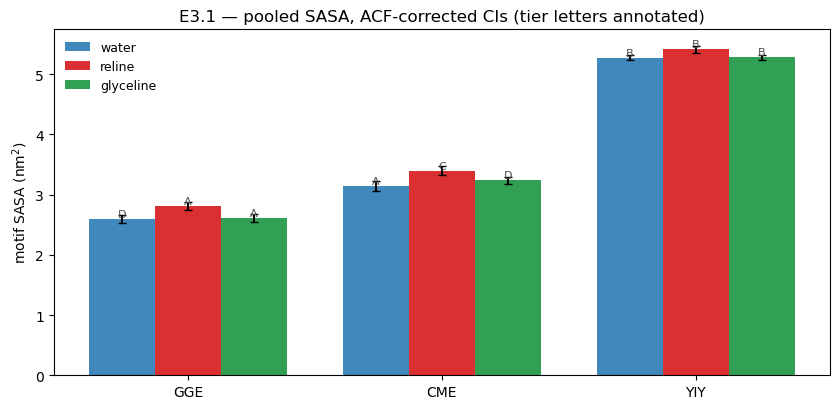

In [27]:
# figure: SASA by system, grouped by peptide, tier-annotated, corrected CIs
fig, ax = plt.subplots(figsize=(8.5, 4.2))
col = {"water":"#2c7bb6","reline":"#d7191c","glyceline":"#1a9641"}
x = np.arange(len(PEPTIDES)); w = 0.26
for k, solv in enumerate(SOLVENTS):
    ys  = [sasa[f"{p}_{solv}"][0]  for p in PEPTIDES]
    es  = [sasa[f"{p}_{solv}"][1]  for p in PEPTIDES]
    trs = [TIER[f"{p}_{solv}"]     for p in PEPTIDES]
    bars = ax.bar(x + (k-1)*w, ys, w, yerr=es, capsize=3,
                  color=col[solv], label=solv, alpha=0.9)
    for b, tr in zip(bars, trs):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), tr,
                ha="center", va="bottom", fontsize=8, color="0.3")
ax.set_xticks(x); ax.set_xticklabels(PEPTIDES)
ax.set_ylabel("motif SASA (nm$^2$)")
ax.set_title("E3.1 — pooled SASA, ACF-corrected CIs (tier letters annotated)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "e3.1_sasa_by_system.png"), dpi=200)
plt.show()

## §2a — E3.2: qualitative present/absent matrix (cutoff-free)

The direct-vs-indirect adjudication needs no recomputation: against the water
null (no DES side-chain shells), a resolved DES shell is direct contact; SASA
moving without one is consistent with the indirect restructuring hypothesis.
Resolved shells are read via the `structured_shell` flag (reportable nulls have
`structured_shell == False` and a NaN cutoff, and are correctly excluded).

In [28]:
def resolved_shells(system, which):
    df = data[system][which]
    if df is None or len(df) == 0:
        return []
    out = []
    for _, r in df.iterrows():
        ok = True
        if COL["resolved"] in df.columns:
            ok = bool(r[COL["resolved"]])
        elif COL["cutoff_nm"] in df.columns:
            ok = pd.notna(r[COL["cutoff_nm"]])
        if ok:
            out.append((str(r[COL["site"]]), str(r[COL["partner"]]),
                        r.get(COL["cutoff_nm"], np.nan),
                        r.get(COL["coord"], np.nan),
                        r.get(COL["per_atom"], np.nan)))
    return out

rows = []
for s in SYSTEMS:
    pep, solv = s.split("_")[0], s.split("_",1)[1]
    for which in ("backbone", "sidechain"):
        for site, partner, cut, coord, per_atom in resolved_shells(s, which):
            rows.append({"peptide": pep, "solvent": solv, "scope": which,
                         "site": site, "partner": partner, "cutoff_nm": cut,
                         "coordination": coord, "per_atom": per_atom})
long = pd.DataFrame(rows)

# present/absent matrix: partners coordinating each (peptide, scope, site) by solvent
def _agg(g):
    return ", ".join(sorted(set(g["partner"]))) if len(g) else "—"
matrix = (long.groupby(["peptide","scope","site","solvent"])
              .apply(_agg).unstack("solvent").reindex(columns=SOLVENTS).fillna("—"))
matrix.to_csv(os.path.join(OUTDIR, "e3.2_coordination_matrix.csv"))
print(matrix.to_string())

solvent                         water                              reline                       glyceline
peptide scope     site                                                                                   
CME     backbone  backbone_O  water_O                  choline_N, water_O              choline_N, water_O
        sidechain motif_Cys         —           choline_N, urea_N, urea_O           choline_N, glycerol_O
                  motif_Glu   water_O          choline_N, urea_N, water_O  choline_N, glycerol_O, water_O
                  motif_Met         —                   choline_N, urea_N                       choline_N
GGE     backbone  backbone_O  water_O  choline_N, urea_N, urea_O, water_O              choline_N, water_O
        sidechain flank_Glu   water_O          choline_N, urea_N, water_O  choline_N, glycerol_O, water_O
                  motif_Glu   water_O          choline_N, urea_N, water_O  choline_N, glycerol_O, water_O
YIY     backbone  backbone_O  water_O  choline

/var/folders/85/m_8pdrwj7879188tqrb7mkqh0000gn/T/ipykernel_1941/1592745977.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg).unstack("solvent").reindex(columns=SOLVENTS).fillna("—"))


Read this against the water column: entries there should be water/none. A DES
partner appearing in the reline/glyceline column where water shows `—` is the
direct-contact signal; its **magnitude** across solvents is deferred to §2b at a
matched cutoff. Qualitative observations already legible here (urea–backbone
present GGE/YIY absent CME; glycerol side-chain at CME Cys/Glu and YIY Tyr;
CME sulfur solvation cosolvent-specific) are recorded as such, framed as
hypotheses for the synthesis.

## §3 — E3.3: YIY backbone H-bonds (per-start; direction robustness)

The metric is already matched across the YIY row (1 ps, backbone N→O, continuous
episodes), so this is a per-start reduction. Episodes sum across starts; the
distinct-bond count ("turns") does **not** (a bond recurs across starts), so
turns is taken system-level from `hbond_lifetimes` (`n_distinct_bonds`) while
per-start `n_bonds` is used only to flag the zero-bond start. The test: does
"reline is the low-H-bond arm" survive removing that zero-bond start?

In [29]:
YIY = [f"YIY_{s}" for s in SOLVENTS]

per_start = []
for s in YIY:
    df = data[s]["hbond_perstart"].copy()
    df["system"] = s; df["solvent"] = s.split("_",1)[1]
    per_start.append(df)
per_start = pd.concat(per_start, ignore_index=True)
keep = [COL["start"], COL["episodes"], COL["bonds"], "system", "solvent"]
per_start = per_start[[c for c in keep if c in per_start.columns]]
print(per_start.to_string(index=False))

# system-level distinct backbone bonds ("turns") from hbond_lifetimes
life = pd.concat([data[s]["hbond_life"].assign(solvent=s.split("_",1)[1]) for s in YIY],
                 ignore_index=True)
distinct = life.set_index("solvent")[COL["distinct_bonds"]].reindex(SOLVENTS)

def ep_totals(df):
    return df.groupby("solvent")[COL["episodes"]].sum().reindex(SOLVENTS)

full_ep = ep_totals(per_start)
noz_ep  = ep_totals(per_start[per_start[COL["bonds"]] > 0])

row = pd.DataFrame({
    "episodes_all":           full_ep,
    "episodes_excl_zerobond": noz_ep,
    "distinct_bonds":         distinct,
    "n_starts":       per_start.groupby("solvent")[COL["start"]].nunique().reindex(SOLVENTS),
    "zerobond_starts": (per_start[per_start[COL["bonds"]]==0]
                        .groupby("solvent")[COL["start"]].nunique()
                        .reindex(SOLVENTS).fillna(0).astype(int)),
})
print("\n", row.to_string())

order_full = list(full_ep.sort_values().index)
order_noz  = list(noz_ep.sort_values().index)
print(f"\nepisode ordering (all)      : {' < '.join(order_full)}")
print(f"episode ordering (excl. 0)  : {' < '.join(order_noz)}")
print(f"reline is low-arm (all)     : {order_full[0]=='reline'}")
print(f"reline is low-arm (excl. 0) : {order_noz[0]=='reline'}")

per_start.to_csv(os.path.join(OUTDIR, "e3.3_yiy_hbond_per_start.csv"), index=False)
row.to_csv(os.path.join(OUTDIR, "e3.3_yiy_row_totals.csv"))

   start  n_episodes  n_bonds        system   solvent
 compact       34007        3     YIY_water     water
extended        9761        2     YIY_water     water
     mid       11074        2     YIY_water     water
    open        9743        2     YIY_water     water
 compact       22335        3    YIY_reline    reline
extended       13773        2    YIY_reline    reline
     mid           0        0    YIY_reline    reline
    open        9570        2    YIY_reline    reline
 compact       16932        3 YIY_glyceline glyceline
extended       16679        2 YIY_glyceline glyceline
     mid       14495        2 YIY_glyceline glyceline
    open       14575        3 YIY_glyceline glyceline

            episodes_all  episodes_excl_zerobond  distinct_bonds  n_starts  zerobond_starts
solvent                                                                                   
water             64585                   64585               4         4                0
reline            45678

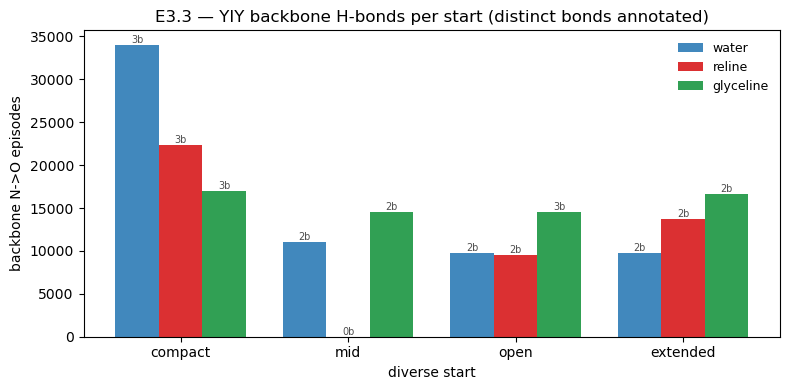

In [13]:
# figure: per-start episodes by solvent, distinct-bond count annotated per bar
fig, ax = plt.subplots(figsize=(8, 4))
col = {"water":"#2c7bb6","reline":"#d7191c","glyceline":"#1a9641"}
xs = np.arange(len(STARTS)); w = 0.26
for k, solv in enumerate(SOLVENTS):
    sub = per_start[per_start.solvent==solv].set_index(COL["start"]).reindex(STARTS)
    ep  = sub[COL["episodes"]].values
    nb  = sub[COL["bonds"]].values
    bars = ax.bar(xs + (k-1)*w, ep, w, color=col[solv], label=solv, alpha=0.9)
    for b, n in zip(bars, nb):
        if np.isfinite(b.get_height()):
            ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                    f"{int(n) if np.isfinite(n) else 0}b",
                    ha="center", va="bottom", fontsize=7, color="0.3")
ax.set_xticks(xs); ax.set_xticklabels(STARTS)
ax.set_ylabel("backbone N->O episodes"); ax.set_xlabel("diverse start")
ax.set_title("E3.3 — YIY backbone H-bonds per start (distinct bonds annotated)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "e3.3_yiy_hbond_per_start.png"), dpi=200)
plt.show()

## §4 — Synthesis scaffold (deterministic from the section outputs)

Assembles the cross-solvent write-up from the §1–§3 tables (and §2b if cached),
as observations/hypotheses with `[REF]` placeholders. Values are inserted from
the computed frames so the document stays a function of the outputs, not authored
by hand. Prose stays hedged: hypotheses supported by the data, tier-aware, no
generalisation beyond the matrix. Edit the interpretive lines in place; re-running
regenerates the numeric slots only.

In [30]:
# §4 — synthesis scaffold (reads §1–§3 committed outputs; hedged, tier-aware)
matched_path = os.path.join(OUTDIR, "e3.2_matched_cutoff.csv")
matched_note = ("present (see §2b)" if os.path.exists(matched_path)
                else "PENDING — run §2b for matched-cutoff magnitudes")

L = []
L.append("# E3.x Cross-Solvent Synthesis\n")
L.append("Observations and hypotheses read across the nine per-system E3.x "
         "summaries at matched cutoffs. Supported by the committed section "
         "outputs; not conclusions of the phase. External refs as [REF].\n")

# ---- E3.1 -----------------------------------------------------------------
L.append("\n## E3.1 — SASA significance\n")
rel = e31[e31.contrast.str.startswith("reline")]
gly = e31[e31.contrast.str.startswith("glyceline")]
L.append(f"- Across the matrix, all three reline contrasts exclude zero "
         f"({', '.join(f'{r.peptide} {r.dSASA_nm2:+.3f}' for _, r in rel.iterrows())}) "
         f"and all three glyceline contrasts include it "
         f"({', '.join(f'{r.peptide} {r.dSASA_nm2:+.3f}' for _, r in gly.iterrows())}): "
         "under corrected CIs the SASA-opening signal segregates with reline, not glyceline. [REF]")
for _, r in e31.iterrows():
    v = "excludes zero" if r.excludes_zero else "includes zero"
    tail = f" — {r.note}" if r.note else ""
    L.append(f"  - {r.peptide} {r.contrast}: {r.dSASA_nm2:+.3f} "
             f"[{r.lo:+.3f}, {r.hi:+.3f}] nm^2, corrected 95% CI {v}{tail}.")
# load-bearing GGE_glyceline against the separated water basins
b = data["GGE_water"]["tier_sasa"].iloc[0]
L.append(f"- Load-bearing (GGE_glyceline): the carried Phase-3 effect size (1.18) does "
         f"not survive — dSASA +0.022 [-0.069, +0.114] includes zero. The water baseline "
         f"is tier-D bimodal (high {b.high_mean:.3f}±{b.high_ci95:.3f}, "
         f"low {b.low_mean:.3f}±{b.low_ci95:.3f}); glyceline (2.612) falls between the "
         f"basins, so the null reflects baseline non-equilibrium as much as any glyceline "
         f"effect. Equilibrium water populations are deferred (Paper 2). [REF]")
L.append(f"- GGE_reline (2.806) coincides with the high water basin ({b.high_mean:.3f}), "
         f"not the pooled mean, so its +0.216 against the pooled baseline is a "
         f"direction-robust, magnitude-provisional estimate. [REF]")

# ---- E3.2 -----------------------------------------------------------------
L.append("\n## E3.2 — direct contact vs indirect restructuring\n")
L.append(f"- Matched-cutoff magnitudes: {matched_note}.")
L.append("- Choline coordinates the backbone and most side chains in BOTH DES (shared "
         "cation); urea/glycerol contacts sit on top of that common layer. Direct DES "
         "contact is therefore not the discriminating variable. [REF]")
L.append("- Glyceline makes direct contact across all peptides (choline throughout; "
         "glycerol at side chains; glycerol at the YIY backbone) yet opens SASA on none — "
         "so contact is not sufficient for opening, which co-segregates specifically with "
         "reline (urea vs glycerol is the differentiating component). [REF]")
L.append("- CME is the internal control: CME_reline opens SASA (+0.248) with NO urea–"
         "backbone shell (urea reaches only Cys/Met/Glu side chains), so opening there "
         "cannot be attributed to direct urea–backbone binding — the cleanest support for "
         "an indirect / side-chain-mediated route. GGE and YIY remain ambiguous (urea "
         "contacts their backbones). Adjudication awaits the §2b water-coordination test. [REF]")

# ---- E3.3 -----------------------------------------------------------------
L.append("\n## E3.3 — YIY backbone H-bond direction\n")
yiy_ps = pd.read_csv(os.path.join(OUTDIR, "e3.3_yiy_hbond_per_start.csv"))
zb = yiy_ps[(yiy_ps.solvent=="reline") & (yiy_ps[COL["bonds"]]==0)][COL["start"]].tolist()
L.append(f"- Episode ordering: reline < glyceline < water, invariant to dropping the "
         f"zero-bond start (that start contributes zero episodes, so totals are unchanged). "
         f"This inverts the Phase-3 region-only, strided framing. [REF]")
L.append(f"- The reline deficit is not a distributed suppression: three of four reline "
         f"starts sit in the other solvents' range; the row gap is carried entirely by the "
         f"{', '.join(zb) if zb else 'mid'} start collapsing to 0 turns, a state the other "
         f"solvents' matched starts do not visit. The result is robust as an ordering but "
         f"rests on one non-ergodic start (consistent with the tier-B non-ergodic backbone "
         f"verdict), so it is a hypothesis about a reline-accessible zero-turn state, not an "
         f"established ensemble-mean suppression. [REF]")

synth = "\n".join(L)
with open(os.path.join(OUTDIR, "E3x_cross_solvent_synthesis.md"), "w") as fh:
    fh.write(synth + "\n")
print(synth)

# E3.x Cross-Solvent Synthesis

Observations and hypotheses read across the nine per-system E3.x summaries at matched cutoffs. Supported by the committed section outputs; not conclusions of the phase. External refs as [REF].


## E3.1 — SASA significance

- Across the matrix, all three reline contrasts exclude zero (GGE +0.216, CME +0.248, YIY +0.135) and all three glyceline contrasts include it (GGE +0.022, CME +0.090, YIY +0.002): under corrected CIs the SASA-opening signal segregates with reline, not glyceline. [REF]
  - GGE reline - water: +0.216 [+0.122, +0.309] nm^2, corrected 95% CI excludes zero — water baseline tier-D (ensemble, not equilibrium).
  - GGE glyceline - water: +0.022 [-0.069, +0.114] nm^2, corrected 95% CI includes zero — water baseline tier-D (ensemble, not equilibrium).
  - CME reline - water: +0.248 [+0.133, +0.364] nm^2, corrected 95% CI excludes zero.
  - CME glyceline - water: +0.090 [-0.014, +0.193] nm^2, corrected 95% CI includes zero — des tier-D (ensembl

## §2b — E3.2: matched-cutoff coordination (guarded, cached, one pass)

**The only trajectory-touching section.** Per-system coordination used
pair-specific first-shell cutoffs, so magnitudes are not comparable across
solvents. This recomputes each resolved (reference, partner) at a **common**
cutoff per pair-type — derived from the committed `rdf_cutoffs.csv`
(`first_min_nm`), not invented — using the same estimator as the per-system
phase (total count of partner atoms within the cutoff, ACF-corrected CI).

It additionally forces `(site, water_O)` across **all three solvents** for every
site that resolves a water shell in any solvent. That is the sharper E3.2 signal:
the indirect-restructuring hypothesis predicts hydration at a site changes across
solvents even where no DES shell forms, which is exactly a matched-cutoff
water-coordination comparison — not visible in the qualitative matrix.

Design, per the calibration (5.1 s/load, 899 waters, 0.8 s/water-RDF → full pass
≈ 5–10 min): **one system at a time, load its four starts once, compute every
matched-cutoff pair for that system in the same pass, write, free.** Loads
dominate and are fixed, so recomputing all pairs (plus the already-common-cutoff
pairs as QC) is the efficient choice. Guarded by the cache so it runs once.

**Verify before first run** (the four provenance items):
1. `SEL` atom-selection strings and reference/partner **labels** against a real
   reline/glyceline coordination CSV — the water system confirms `backbone_O`,
   `motif_Cys/Met/Glu`; `motif_Tyr` and the DES partner labels (`urea_O`,
   `urea_N`, `glycerol_O`, `chloride`) are inferred.
2. `MATCHED_RULE` — how the common cutoff is chosen per pair-type (default `max`,
   capturing the full first shell across solvents).
3. The `convergence_stats` import path and `compute_stat` signature.
4. That the per-system coordination used this same traj root / stride / window
   (the calibration confirmed format and window match).

In [31]:
CACHE = os.path.join(OUTDIR, "e3.2_matched_cutoff.csv")

if os.path.exists(CACHE):
    matched = pd.read_csv(CACHE)
    print(f"loaded cached matched-cutoff coordination ({len(matched)} rows) — skipping recompute")
else:
    import mdtraj as _md
    sys.path.insert(0, CONV)
    try:
        import convergence_stats as cs   # E2.2 module: compute_stat(series) -> mean, ci95, ...
        HAVE_CS = True
    except Exception as e:
        HAVE_CS = False
        print(f"[check] convergence_stats import failed ({e}); falling back to raw CI (understates)")

    # ---- selections keyed by CSV reference/partner labels (verify vs prmtop) --
    SEL = {
        "backbone_O": "protein and name O",
        "motif_Tyr":  "resname TYR and name OH",
        "motif_Cys":  "resname CYS CYX and name SG",
        "motif_Met":  "resname MET and name SD",
        "motif_Glu":  "resname GLU and name OE1 OE2",
        "water_O":    "water and name O",
        "urea_O":     "resname URE and name O",
        "urea_N":     "resname URE and name N1 N2",
        "glycerol_O": "resname GOL and name O1 O2 O3",
        "chloride":   "resname CLA",
    }

    # ---- matched cutoff per (reference, partner) from committed first_min_nm --
    MATCHED_RULE = "max"   # {"max","mean","min"} — max captures the full first shell everywhere
    cut_rows = []
    for s in SYSTEMS:
        rc = data[s]["rdf_cutoffs"]
        if rc is None: continue
        for _, r in rc.iterrows():
            v = r[COL["first_min"]]
            if pd.isna(v): continue
            cut_rows.append({"site": str(r[COL["site"]]), "partner": str(r[COL["partner"]]),
                             "solvent": s.split("_",1)[1], "cutoff_nm": float(v)})
    cuts = pd.DataFrame(cut_rows)
    matched_cut = (cuts.groupby(["site","partner"])["cutoff_nm"].agg(MATCHED_RULE)
                        .rename("matched_cutoff_nm").reset_index())
    print("matched cutoffs per pair-type:")
    print(matched_cut.to_string(index=False))

    # ---- recompute set: every resolved (site,partner) in the matrix ...
    want = matched_cut.merge(
        long[["peptide","solvent","site","partner"]].drop_duplicates(),
        on=["site","partner"], how="inner")

    # ... plus (site, water_O) across ALL solvents, per peptide where water resolves
    aug = []
    for p in PEPTIDES:
        sites_p = long.loc[(long.peptide==p) & (long.partner=="water_O"), "site"].unique()
        for st in sites_p:
            for sv in SOLVENTS:
                aug.append({"site": st, "partner": "water_O", "peptide": p, "solvent": sv})
    aug = pd.DataFrame(aug).merge(matched_cut, on=["site","partner"], how="left")
    want = (pd.concat([want, aug], ignore_index=True)
              .dropna(subset=["matched_cutoff_nm"])
              .drop_duplicates(["peptide","solvent","site","partner"]))

    def _count_within(traj, sel_a, sel_b, cutoff, chunk=500):
        top = traj.topology
        a = top.select(sel_a); b = top.select(sel_b)
        if len(a)==0 or len(b)==0:
            return None, 0
        pairs = np.array([[i, j] for i in a for j in b])
        counts = []
        for k in range(0, traj.n_frames, chunk):
            d = _md.compute_distances(traj[k:k+chunk], pairs)
            counts.extend((d < cutoff).sum(axis=1).tolist())
        return np.asarray(counts, float), len(a)   # total per frame (matches pooled_coord); n_ref

    out_rows = []
    for s in SYSTEMS:
        pep, solv = s.split("_")[0], s.split("_",1)[1]
        pairs_here = want[(want.peptide==pep) & (want.solvent==solv)]
        if pairs_here.empty:
            continue
        t0 = time.perf_counter()
        for start in STARTS:
            p = traj_path(s, start)
            if not os.path.isfile(p):
                print(f"  [skip] {s} {start}: {p} not found"); continue
            tr = _md.load(p, top=top_path(s), stride=STRIDE)[WIN_START_FRAME:]
            for _, pr in pairs_here.iterrows():
                sa = SEL.get(pr.site); sb = SEL.get(pr.partner)
                if sa is None or sb is None:
                    print(f"  [check] no SEL for {pr.site}/{pr.partner}"); continue
                series, n_ref = _count_within(tr, sa, sb, pr.matched_cutoff_nm)
                if series is None:
                    continue
                if HAVE_CS:
                    st = cs.compute_stat(series, dt_ps=float(STRIDE))
                    m, ci = st["mean"], st["ci95"]
                else:
                    m, ci = float(series.mean()), 1.96 * series.std() / np.sqrt(len(series))
                out_rows.append({"system": s, "peptide": pep, "solvent": solv,
                                 "site": pr.site, "partner": pr.partner,
                                 "matched_cutoff_nm": pr.matched_cutoff_nm,
                                 "start": start, "coord": m, "per_atom": m/max(n_ref,1),
                                 "ci95": ci})
        print(f"  {s}: {len(pairs_here)} pairs x starts in {time.perf_counter()-t0:.1f}s")

    per_start_m = pd.DataFrame(out_rows)
    # pool across starts: mean of per-start means; CI combined in quadrature / k
    matched = (per_start_m.groupby(["system","peptide","solvent","site","partner","matched_cutoff_nm"])
               .agg(coord=("coord","mean"), per_atom=("per_atom","mean"),
                    ci95=("ci95", lambda v: float(np.sqrt(np.sum(np.square(v)))/len(v))),
                    n_starts=("start","nunique"))
               .reset_index())
    matched.to_csv(CACHE, index=False)
    print(f"\nwrote {CACHE} ({len(matched)} pooled rows)")

print(matched.head(20).to_string(index=False))

matched cutoffs per pair-type:
      site    partner  matched_cutoff_nm
backbone_O  choline_N              0.423
backbone_O glycerol_O              0.322
backbone_O     urea_N              0.423
backbone_O     urea_O              0.562
backbone_O    water_O              0.338
 flank_Glu  choline_N              0.527
 flank_Glu glycerol_O              0.317
 flank_Glu     urea_N              0.392
 flank_Glu    water_O              0.327
 motif_Cys  choline_N              0.442
 motif_Cys glycerol_O              0.412
 motif_Cys     urea_N              0.447
 motif_Cys     urea_O              0.377
 motif_Glu  choline_N              0.548
 motif_Glu glycerol_O              0.317
 motif_Glu     urea_N              0.392
 motif_Glu    water_O              0.327
 motif_Met  choline_N              0.447
 motif_Met     urea_N              0.433
 motif_Tyr   chloride              0.382
 motif_Tyr glycerol_O              0.538
 motif_Tyr     urea_N              0.387
 motif_Tyr     urea_O     

In [ ]:
# QC: pairs already at a common cutoff should reproduce the stored pooled_coord
if "matched" in dir() and len(matched):
    qc = matched.merge(long, on=["peptide","solvent","site","partner"],
                       how="inner", suffixes=("_matched","_stored"))
    if len(qc):
        qc["abs_diff"] = (qc["coord"] - qc["coordination"]).abs()
        print("recompute vs stored (common-cutoff pairs are the meaningful QC):")
        print(qc[["system","site","partner","matched_cutoff_nm","coord","coordination","abs_diff"]]
              .sort_values("abs_diff", ascending=False).head(15).to_string(index=False))
        print("\nLarge diffs on differing-cutoff pairs are expected (that is the point);")
        print("large diffs on already-common-cutoff pairs flag estimator drift — inspect before synthesis.")

### Fold §2b into the synthesis

With the cache written, re-run **§4** to insert the matched-cutoff magnitudes:
the pending line resolves to the direct-vs-indirect magnitude comparison per
observable — including the water-coordination-across-solvents test that is the
core indirect-restructuring signal. Every subsequent notebook run reads the
cache and skips the recompute.